## Human labels vs slant estimator

In [44]:
from pathlib import Path
import sys
import pandas as pd
import asyncio

ROOT = Path("../")
sys.path.append(str(ROOT / "src"))

from classifier import inference
from data_fetcher import get_videos_metadata
from models import Video

In [ ]:
path = "../data/slant/human_labels/"
csv = [pd.read_csv(f) for f in Path(path).glob("results_2021*.csv")]
df = pd.concat(csv,ignore_index=True)

# filter out non ideological labels
df = df[df["label_name"] != "One or both of the videos is not ideological"]
df = df.rename(columns={"label_name": "human_label"})

/var/folders/p6/8cdyrdjx0bb9nc27_9f01gpw0000gn/T/ipykernel_10867/714316081.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_con["human_label"] = df_con["human_label"].map(label_map)
/var/folders/p6/8cdyrdjx0bb9nc27_9f01gpw0000gn/T/ipykernel_10867/714316081.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lib["human_label"] = df_lib["human_label"].map(label_map)


In [30]:
# generate video objects with metadata

ids = pd.unique(pd.concat([df["bottom_video_id"], df["top_video_id"]], ignore_index=True))
vids = [Video(id=str(id)) for id in ids]
chunks = [vids[i:i+49] for i in range(0, len(vids), 49)]

print(ids)

async def get_videos():
    results = await asyncio.gather(*(get_videos_metadata(c) for c in chunks))
    return [v for sub in results for v in sub]

vids_metadata = await get_videos()
print(vids_metadata[:5])


['vipqI7SCgjA' 'q5Gr9SQmkfc' 'fyF1pepEpDE' ... '6ex9n959XhQ' '2ZabLF4R5Os'
 'A-SmKj3zCKU']
[Video(id='vipqI7SCgjA', slant=None, title='Trump Gets CLOBBERED By A Nurse', channel='The Damage Report', description='Donald Trump gets clobbered by a nurse. John Iadarola and Francesca Fiorentini react on The Damage Report. Follow The Damage Report on Facebook: https://www.facebook.com/TheDamageReportTYT/\n\nHelp build the Home of the Progressives http://tyt.com/JOIN\n\nSubscribe to The Damage Report YouTube channel: https://www.youtube.com/thedamagereport?sub_confirmation=1\n\nFollow The Damage Report on Twitter: https://twitter.com/TheDamageReport\n\nRead more here: https://www.mediaite.com/trump/what-do-i-know-im-not-a-doctor-trump-touts-unproven-coronavirus-drug-at-briefing/\n\n"President\xa0Donald Trump\xa0lambasted the governor of Illinois and pushed an unproven drug for coronavirus at the White House press briefing on Sunday.\n\nThe daily briefing was not expected to go forward, until T

In [48]:
# generate video slants
vids_metadata = inference.predict(vids_metadata)

2025-10-17 23:16:05 [INFO] Inference: Predicted 2382 video slants in 97.97045302391052 seconds.


In [49]:
#save to file
rows = [
    {
        "video_id": v.id,
        "video_obj": v
    }
    for v in vids_metadata
]
vid_df = pd.DataFrame.from_records(rows)
vid_df.to_pickle("../data/slant/human_labels/vid_metadata.pkl")

In [71]:
df_merged = (
    df
    .merge(vid_df, how="left", left_on="top_video_id", right_on="video_id")
    .rename(columns={"video_obj": "top_video_obj"})
    .drop(columns=["video_id"])
    .merge(vid_df, how="left", left_on="bottom_video_id", right_on="video_id")
    .rename(columns={"video_obj": "bottom_video_obj"})
    .drop(columns=["video_id"])
)
df_merged = df_merged[df_merged["top_video_obj"].notna()]
df_merged = df_merged[df_merged["bottom_video_obj"].notna()]

# slant labels
df_merged["top_slant_pred"] = [vid.slant for vid in df_merged["top_video_obj"].to_list()]
df_merged["bottom_slant_pred"] = [vid.slant for vid in df_merged["bottom_video_obj"].to_list()]

label_map = {
    "The top video is more right leaning than the bottom video": "top",
    "The top video is more left leaning than the bottom video": "top",
    "The bottom video is more left leaning than the top video": "bot",
    "The bottom video is more right leaning than the top video": "bot"
}

df_merged["human_label"] = df_merged["human_label"].map(label_map)

In [85]:
#split df
df_con = df_merged[df_merged["category_name"] == "Indicate which video is more conservative"]
df_lib = df_merged[df_merged["category_name"] == "Indicate which video is more liberal"]

def label_pred(row, con : bool):
    if con:
        if row["top_slant_pred"] > row["bottom_slant_pred"]: return "top"
        else: return "bot"
    else:
        if row["top_slant_pred"] > row["bottom_slant_pred"]: return "bot"
        else: return "top"

df_lib["pred_label"] = df_lib.apply(label_pred, axis=1, args=(False,))
df_con["pred_label"] = df_con.apply(label_pred, axis=1, args=(True,))
final_df = pd.concat([df_lib, df_con], ignore_index=True)
final_df["agree"] = final_df.apply(lambda row: True if row["pred_label"] == row["human_label"] else False, axis=1)
final_df["dist"] = final_df.apply(lambda row: abs(row["top_slant_pred"] - row["bottom_slant_pred"]), axis=1)


/var/folders/p6/8cdyrdjx0bb9nc27_9f01gpw0000gn/T/ipykernel_10867/2875744663.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lib["pred_label"] = df_lib.apply(label_pred, axis=1, args=(False,))
/var/folders/p6/8cdyrdjx0bb9nc27_9f01gpw0000gn/T/ipykernel_10867/2875744663.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_con["pred_label"] = df_con.apply(label_pred, axis=1, args=(True,))


In [86]:
final_df.to_pickle("../data/slant/human_labels/labels.pkl")

In [ ]:
final_df

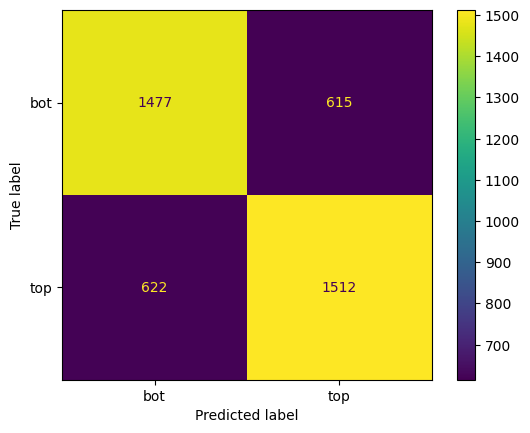

In [82]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(final_df["human_label"], final_df["pred_label"])

In [87]:
from sklearn.metrics import classification_report

print(classification_report(final_df["human_label"], final_df["pred_label"]))

              precision    recall  f1-score   support

         bot       0.70      0.71      0.70      2092
         top       0.71      0.71      0.71      2134

    accuracy                           0.71      4226
   macro avg       0.71      0.71      0.71      4226
weighted avg       0.71      0.71      0.71      4226



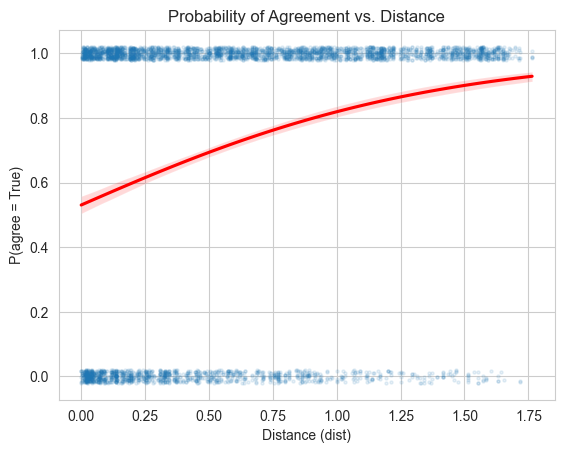

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

sns.regplot(
    data=final_df,
    x="dist",
    y="agree",
    logistic=True,
    ci=95,
    scatter_kws={"s": 5, "alpha": 0.1},
    line_kws={"color": "red"},
    y_jitter=0.02
)

plt.title("Probability of Agreement vs. Distance")
plt.ylabel("P(agree = True)")
plt.xlabel("Distance (dist)")
plt.show()

In [100]:
import statsmodels.api as sm
import numpy as np

# Prepare data
X = final_df["dist"]
y = final_df["agree"].astype(int)

# Add constant for intercept
X = sm.add_constant(X)

# Fit logistic regression
model = sm.Logit(y, X)
result = model.fit()

print(result.summary())


Optimization terminated successfully.
         Current function value: 0.565204
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  agree   No. Observations:                 4226
Model:                          Logit   Df Residuals:                     4224
Method:                           MLE   Df Model:                            1
Date:                Sat, 18 Oct 2025   Pseudo R-squ.:                 0.06510
Time:                        00:24:33   Log-Likelihood:                -2388.6
converged:                       True   LL-Null:                       -2554.9
Covariance Type:            nonrobust   LLR p-value:                 2.542e-74
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1225      0.053      2.321      0.020       0.019       0.226
dist           1.3894      0.

In [104]:
bins = [0, 0.5, 1.0, 1.5, 2.0]
final_df["Score distance"] = pd.cut(final_df["dist"], bins=bins)

table = (
    final_df.groupby("Score distance")
    .agg({"agree": "mean"})
    .rename(columns={"agree": "% Agreement"})
)

table["% Agreement"] = (table["% Agreement"] * 100).round(2)

table

/var/folders/p6/8cdyrdjx0bb9nc27_9f01gpw0000gn/T/ipykernel_10867/1083538295.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final_df.groupby("Score distance")


,% Agreement
Score distance,
"(0.0, 0.5]",59.54
"(0.5, 1.0]",75.70
"(1.0, 1.5]",85.81
"(1.5, 2.0]",91.72
